<a href="https://colab.research.google.com/github/sw030701-ai/motor-control-optimization/blob/main/experiments/04_rl_direct_voltage_control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. RL Direct Voltage Control

이 notebook은 PID gain tuning이 아니라 `RL Direct Voltage Control` 실험을 정리한다.
RL agent는 현재 state `[e_t, omega_t, i_t]`를 보고 매 time step마다 voltage `V_t`를 직접 출력한다.

```text
[e_t, omega_t, i_t] -> TD3 agent -> V_t -> DC motor
```

`V_t`는 실제 actuator limit을 반영해서 `-12 V`부터 `12 V` 사이로 clip한다.

## 실험 방향

기존 PID optimization은 좋은 `K_p`, `K_i`, `K_d`를 찾는 문제이다.
반면 이 실험의 RL controller는 PID 구조를 쓰지 않고, state를 보고 voltage를 직접 결정한다.

| Controller | 제어 방식 |
|---|---|
| Manual PID | 사람이 고정 PID gains를 선택 |
| Optimized PID | optimizer가 고정 PID gains를 탐색 |
| RL Direct Control | TD3 policy가 voltage를 직접 출력 |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULT_TABLE_DIR = PROJECT_ROOT / "results" / "tables"
RESULT_FIGURE_DIR = PROJECT_ROOT / "results" / "figures"

comparison_path = RESULT_TABLE_DIR / "direct_voltage_rl_comparison.csv"
training_history_path = RESULT_TABLE_DIR / "rl_direct_voltage_training_history.csv"
evaluation_path = RESULT_TABLE_DIR / "rl_direct_voltage_evaluation.csv"
speed_plot_path = RESULT_FIGURE_DIR / "rl_direct_voltage_speed_comparison.png"
voltage_plot_path = RESULT_FIGURE_DIR / "rl_direct_voltage_control_comparison.png"

## 고정 조건

비교 조건은 기존 main 실험과 동일하게 둔다.

| 항목 | 값 |
|---|---|
| Motor model | `nominal_dc_motor_params()` |
| Reference speed | `12.6 rad/s` |
| Voltage limit | `-12 V <= V_t <= 12 V` |
| Initial state | `omega(0)=0`, `i(0)=0` |
| Evaluation metric | 기존 `compute_cost()`와 `is_feasible_v1()` |

## TD3 선택 이유

이 실험에서는 `TD3`를 사용한다.
Action이 motor voltage이므로 continuous action이고, action dimension은 1개이다.
따라서 deterministic policy가 voltage를 직접 출력하는 TD3가 현재 v1 실험에 자연스럽다.

`SAC`도 사용할 수 있지만, 이 프로젝트 단계에서는 TD3가 구현 의존성과 tuning 부담이 더 작다.

## Reward 설계

reward는 기존 PID optimization의 cost 철학을 따른다. 즉 tracking error, overshoot, control effort를 모두 반영한다.

```math
r_t = -\left[
0.60\left(\frac{e_t}{\omega_{ref}}\right)^2
+0.25\left(\max\left(0,\frac{\omega_t-\omega_{ref}}{\omega_{ref}}\right)\right)^2
+0.15\left(\frac{V_t}{V_{max}}\right)^2
\right]
```

학습 reward와 최종 evaluation metric이 완전히 같은 것은 아니지만, 둘 다 tracking, overshoot, voltage effort를 보는 같은 방향의 기준이다.

## 학습 과정

아래 표는 초기 100-episode TD3 실행에서 기록한 training history이다.
중간에 reward가 좋아지는 구간이 있었지만, 마지막 policy는 target speed까지 안정적으로 도달하지 못했다.

In [2]:
training_history = pd.read_csv(training_history_path)
display(training_history)

episode,episode_reward,final_omega,final_error,critic_loss,actor_loss
1,-403.066652,-0.396077,12.996077,0.001495,1.193126
2,-384.009056,-0.082708,12.682708,0.027195,NaN
3,-377.906316,0.790635,11.809365,0.000747,2.662505
4,-410.637837,-0.807635,13.407635,0.001807,NaN
5,-431.550853,-1.419690,14.019690,0.001322,4.465323
6,-428.163115,-1.103666,13.703666,0.005216,NaN
7,-437.492943,-1.104329,13.704329,0.003247,6.228038
8,-300.572848,2.004469,10.595531,0.749799,NaN
9,-262.188989,2.654983,9.945017,0.019312,7.194409
10,-213.803364,5.824630,6.775370,0.008821,NaN


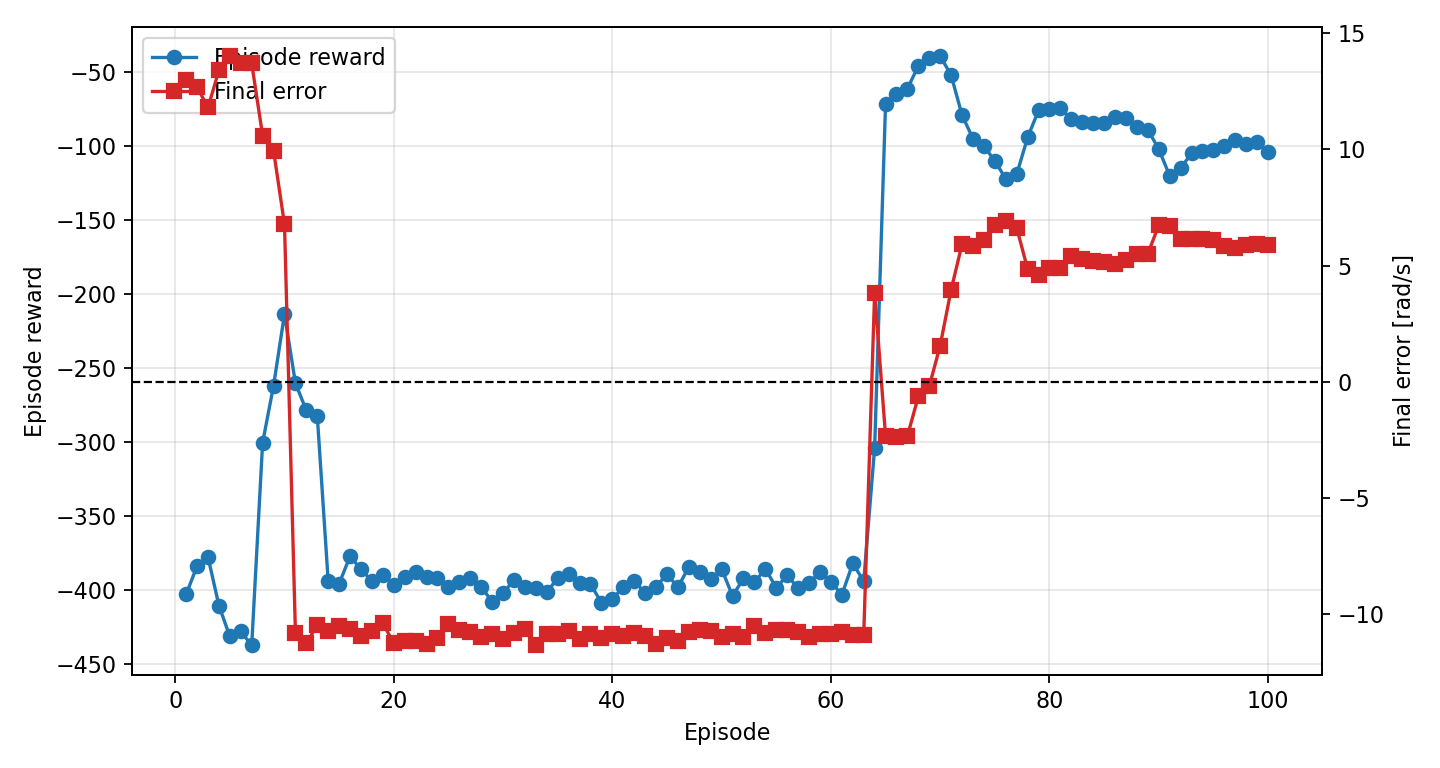

In [3]:
display(Image(filename=str(RESULT_FIGURE_DIR / "rl_direct_voltage_training_history.png")))

## 최종 비교 결과

Manual PID, Optimized PID, RL Direct Control을 같은 `compute_cost()` metric으로 비교한다.
결과적으로 RL Direct Control은 v1 feasibility criteria를 만족하지 못했다.

In [4]:
comparison = pd.read_csv(comparison_path)
show_columns = [
    "Controller",
    "J_total",
    "J_tracking",
    "J_overshoot",
    "J_control",
    "overshoot_percent",
    "settling_time",
    "steady_state_error_percent",
    "voltage_max_abs",
    "saturation_percent",
    "omega_final",
    "feasible",
    "J_improvement_vs_manual_percent",
]
display(comparison[show_columns])

Controller,J_total,J_tracking,J_overshoot,J_control,overshoot_percent,settling_time,steady_state_error_percent,voltage_max_abs,saturation_percent,omega_final,feasible,J_improvement_vs_manual_percent
Manual PID,0.038177,0.000114,0.000000e+00,0.254054,0.00000,1.322,2.158821e-07,10.242803,0.000000,12.600000,True,0.000000
Optimized PID,0.036702,0.000611,7.499755e-09,0.242238,0.00866,1.547,4.709601e-10,6.001635,0.000000,12.600000,True,3.861902
RL Direct Control,0.074851,0.105121,0.000000e+00,0.078521,0.00000,inf,4.584141e+01,11.999998,0.179982,6.823982,False,-96.065613


## RL 평가 결과만 확인

아래 표는 RL Direct Control의 evaluation 결과만 따로 정리한 것이다.

In [5]:
rl_evaluation = pd.read_csv(evaluation_path)
display(rl_evaluation.T.rename(columns={0: "value"}))

metric,value
Controller,RL Direct Control
K_p,NaN
K_i,NaN
K_d,NaN
J_total,0.074851
J_tracking,0.105121
J_overshoot,0.0
J_control,0.078521
overshoot_percent,0.0
settling_time,inf


## 시뮬레이션 응답

아래 plot은 같은 motor, 같은 reference, 같은 voltage limit에서 세 controller의 speed response와 voltage response를 비교한 것이다.

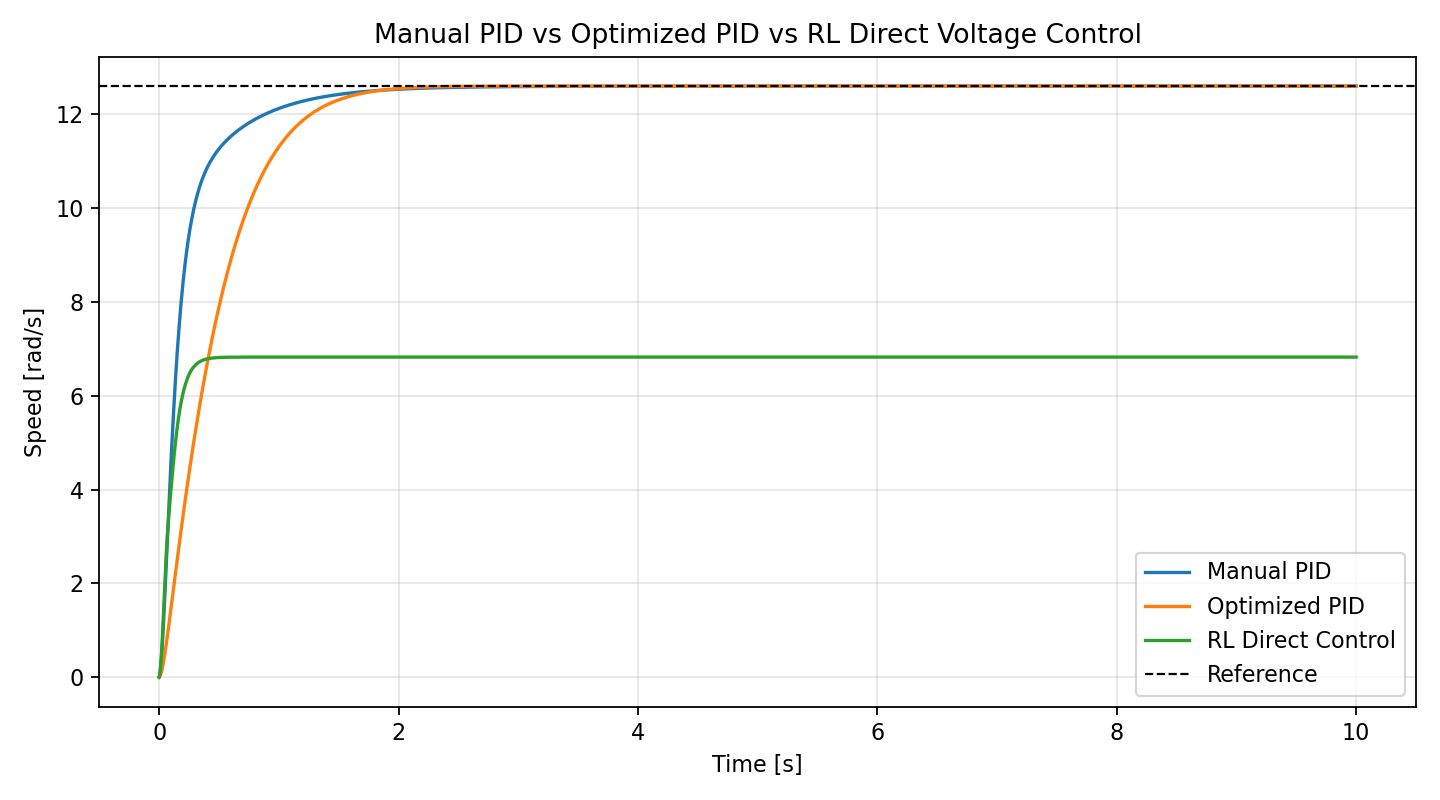

In [6]:
display(Image(filename=str(speed_plot_path)))

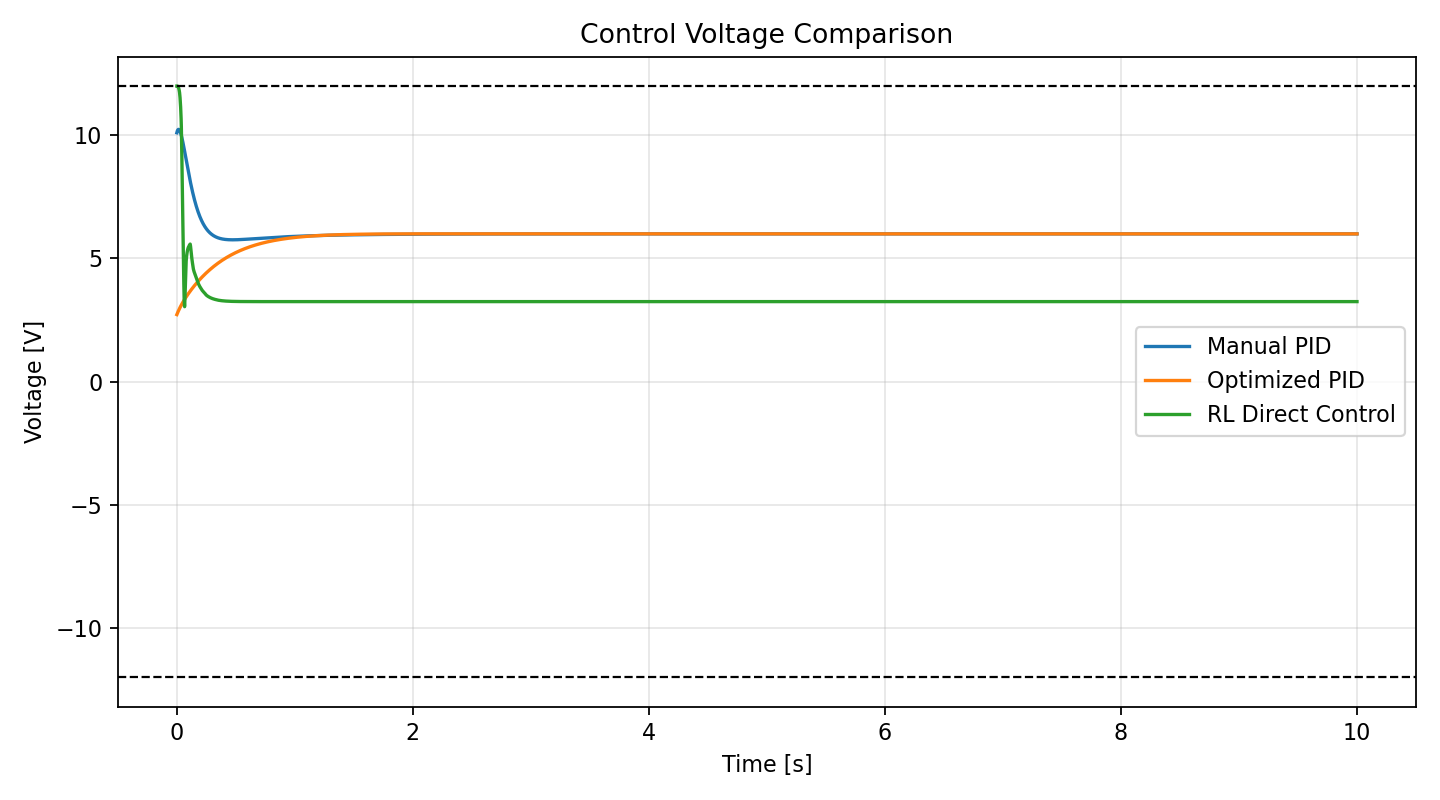

In [7]:
display(Image(filename=str(voltage_plot_path)))

## 결과 해석

초기 100-episode TD3 결과에서 RL Direct Control의 최종 속도는 `6.824 rad/s`이고, target speed는 `12.600 rad/s`이다.
따라서 steady-state error가 `45.84%`로 크게 남았고, settling time도 finite value로 계산되지 않았다.

이 결과는 RL이 항상 PID보다 좋다는 가정을 지지하지 않는다.
현재의 단순 state, reward, training budget에서는 Optimized PID가 더 안정적이고 실용적이다.
따라서 이 프로젝트에서는 RL Direct Control을 성공 사례가 아니라, direct RL control을 적용할 때 추가적인 reward shaping과 학습 안정화가 필요하다는 한계 분석으로 정리한다.